# Parking Analysis: Hourly Arrivals & Duration per Instance

Analysis of cars arriving at each hour and their parking duration for parking instances 1-10.

## 1. Import Required Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load Parking Data

In [19]:
# Load vehicles data
df_vehicles = pd.read_csv('vehicles.csv')

# Convert arrival time from minutes to hours (assuming 0 = midnight)
df_vehicles['arrival_hour'] = (df_vehicles['Arrival_Time'] / 60).astype(int)
df_vehicles['arrival_time_formatted'] = df_vehicles['arrival_hour'].apply(lambda h: f"{h:02d}:00")

# Parking duration is already in minutes
df_vehicles['parking_duration_minutes'] = df_vehicles['Parking_Duration']
df_vehicles['parking_duration_hours'] = df_vehicles['Parking_Duration'] / 60

print(f"Total vehicles: {len(df_vehicles)}")
print(f"\nFirst 10 rows:")
print(df_vehicles[['Vehicle_ID', 'Arrival_Time', 'arrival_hour', 'Parking_Duration']].head(10))

Total vehicles: 1000

First 10 rows:
   Vehicle_ID  Arrival_Time  arrival_hour  Parking_Duration
0           1           420             7               1.0
1           2           420             7               8.0
2           3           421             7               6.0
3           4           425             7               1.0
4           5           426             7               6.0
5           6           427             7               5.0
6           7           428             7               1.0
7           8           430             7               5.0
8           9           432             7               5.0
9          10           433             7               1.0


## 3. Load Parking Instance Information

In [20]:
# Load parking instance metadata for 1-10
parking_instances = {}

for i in range(1, 11):
    parking_file = f'parking{i}.json'
    with open(parking_file) as f:
        parking_instances[i] = json.load(f)

# Summary of parking instances
instance_summary = []
for instance_id, data in parking_instances.items():
    instance_summary.append({
        'Instance': instance_id,
        'Total Capacity': data['total_capacity'],
        'Floors': data['num_floors'],
        'Spots': len(data['spots'])
    })

df_instances = pd.DataFrame(instance_summary)
print("Parking Instance Summary:")
print(df_instances.to_string(index=False))

Parking Instance Summary:
 Instance  Total Capacity  Floors  Spots
        1             417       1    417
        2             377       1    377
        3             271       3    271
        4             485       4    485
        5             428       4    428
        6             444       4    444
        7             432       2    432
        8              98       1     98
        9             486       3    486
       10             100       3    100


## 4. Hourly Arrival Analysis

In [21]:
# Count cars arriving at each hour
hourly_arrivals = df_vehicles['arrival_hour'].value_counts().sort_index()

hourly_summary = pd.DataFrame({
    'Hour': hourly_arrivals.index,
    'Hour_Formatted': hourly_arrivals.index.map(lambda h: f"{h:02d}:00"),
    'Cars_Arriving': hourly_arrivals.values
}).reset_index(drop=True)

print("\n" + "="*60)
print("HOURLY ARRIVALS (All Instances - Same Vehicle Dataset)")
print("="*60)
print(hourly_summary.to_string(index=False))
print(f"\nTotal Cars: {hourly_summary['Cars_Arriving'].sum()}")


HOURLY ARRIVALS (All Instances - Same Vehicle Dataset)
 Hour Hour_Formatted  Cars_Arriving
    7          07:00             38
    8          08:00             21
    9          09:00             20
   10          10:00             20
   11          11:00            100
   12          12:00             99
   13          13:00            104
   14          14:00            109
   15          15:00            101
   16          16:00             85
   17          17:00            123
   18          18:00             67
   19          19:00             55
   20          20:00             41
   21          21:00             17

Total Cars: 1000


## 5. Parking Duration Statistics by Hour

In [22]:
# Duration statistics by arrival hour
duration_by_hour = df_vehicles.groupby('arrival_hour').agg({
    'Parking_Duration': ['count', 'mean', 'median', 'min', 'max', 'std']
}).round(2)

duration_by_hour.columns = ['Count', 'Avg_Duration_min', 'Median_Duration_min', 'Min_Duration_min', 'Max_Duration_min', 'StdDev']
duration_by_hour = duration_by_hour.reset_index()
duration_by_hour.rename(columns={'arrival_hour': 'Hour'}, inplace=True)
duration_by_hour['Hour_Formatted'] = duration_by_hour['Hour'].apply(lambda h: f"{h:02d}:00")

print("\n" + "="*100)
print("PARKING DURATION STATISTICS BY ARRIVAL HOUR")
print("="*100)
print(duration_by_hour[['Hour', 'Hour_Formatted', 'Count', 'Avg_Duration_min', 'Median_Duration_min', 'Min_Duration_min', 'Max_Duration_min']].to_string(index=False))


PARKING DURATION STATISTICS BY ARRIVAL HOUR
 Hour Hour_Formatted  Count  Avg_Duration_min  Median_Duration_min  Min_Duration_min  Max_Duration_min
    7          07:00     38              3.13                  4.0               0.5               8.0
    8          08:00     21              3.19                  3.0               3.0               4.0
    9          09:00     20              2.35                  2.0               2.0               3.0
   10          10:00     20              1.70                  2.0               1.0               2.0
   11          11:00    100              3.17                  3.0               1.0              10.0
   12          12:00     99              3.13                  3.0               1.0               6.0
   13          13:00    104              2.98                  3.0               1.0               6.0
   14          14:00    109              2.82                  3.0               0.5               5.0
   15          15:00    101 

## 6. Individual Vehicle Details (Sample)

In [23]:
# Show detailed vehicle information with formatted times
df_display = df_vehicles[['Vehicle_ID', 'Vehicle_Type', 'Arrival_Time', 'arrival_hour', 
                           'Parking_Duration', 'Departure_Time', 'User_Type', 'Electric_Vehicle']].copy()

# Convert minutes to HH:MM format
def minutes_to_time(minutes):
    hours = int(minutes // 60)
    mins = int(minutes % 60)
    return f"{hours:02d}:{mins:02d}"

df_display['Arrival_Time_Formatted'] = df_display['Arrival_Time'].apply(minutes_to_time)
df_display['Departure_Time_Formatted'] = df_display['Departure_Time'].apply(minutes_to_time)
df_display['Duration_Hours'] = (df_display['Parking_Duration'] / 60).round(2)

print("\n" + "="*140)
print("SAMPLE: FIRST 30 VEHICLES WITH FORMATTED TIMES")
print("="*140)
display_cols = ['Vehicle_ID', 'Vehicle_Type', 'Arrival_Time_Formatted', 'Departure_Time_Formatted', 
                'Parking_Duration', 'Duration_Hours', 'User_Type']
print(df_display[display_cols].head(30).to_string(index=False))


SAMPLE: FIRST 30 VEHICLES WITH FORMATTED TIMES
 Vehicle_ID Vehicle_Type Arrival_Time_Formatted Departure_Time_Formatted  Parking_Duration  Duration_Hours User_Type
          1     Standard                  07:00                    08:00               1.0            0.02   Visitor
          2      Compact                  07:00                    15:00               8.0            0.13     Staff
          3        Large                  07:01                    13:01               6.0            0.10   Visitor
          4     Standard                  07:05                    08:05               1.0            0.02   Visitor
          5      Compact                  07:06                    13:06               6.0            0.10   Visitor
          6     Standard                  07:07                    12:07               5.0            0.08   Visitor
          7     Standard                  07:08                    08:08               1.0            0.02   Visitor
          8     

## 7. Summary Table: Each Instance with Hourly Breakdown

In [24]:
# Since the vehicles.csv is shared across all instances, 
# we show the same arrival/duration data for each instance

print("\n" + "="*100)
print("PARKING INSTANCES 1-10: HOURLY ARRIVAL & DURATION SUMMARY")
print("="*100)
print("\nNote: Same vehicle dataset applies to all 10 instances.")
print("Instances differ in capacity and floor configuration.\n")

for instance_id in range(1, 11):
    print(f"\n{'─'*80}")
    print(f"PARKING INSTANCE {instance_id}")
    print(f"{'─'*80}")
    print(f"Capacity: {parking_instances[instance_id]['total_capacity']} | "
          f"Floors: {parking_instances[instance_id]['num_floors']} | "
          f"Total Spots: {len(parking_instances[instance_id]['spots'])}")
    print()
    
    # Show hourly arrivals for this instance
    print(f"{'Hour':<10} {'Arrivals':<15} {'Avg Duration':<20} {'Total Hours':<15}")
    print("─" * 60)
    
    for _, row in duration_by_hour.iterrows():
        hour = row['Hour']
        count = int(row['Count'])
        avg_duration = row['Avg_Duration_min']
        total_hours = (count * avg_duration / 60)
        print(f"{row['Hour_Formatted']:<10} {count:<15} {avg_duration:.1f} min{'':<10} {total_hours:.1f} hours")


PARKING INSTANCES 1-10: HOURLY ARRIVAL & DURATION SUMMARY

Note: Same vehicle dataset applies to all 10 instances.
Instances differ in capacity and floor configuration.


────────────────────────────────────────────────────────────────────────────────
PARKING INSTANCE 1
────────────────────────────────────────────────────────────────────────────────
Capacity: 417 | Floors: 1 | Total Spots: 417

Hour       Arrivals        Avg Duration         Total Hours    
────────────────────────────────────────────────────────────
07:00      38              3.1 min           2.0 hours
08:00      21              3.2 min           1.1 hours
09:00      20              2.4 min           0.8 hours
10:00      20              1.7 min           0.6 hours
11:00      100             3.2 min           5.3 hours
12:00      99              3.1 min           5.2 hours
13:00      104             3.0 min           5.2 hours
14:00      109             2.8 min           5.1 hours
15:00      101             2.6 min  

## 8. Visualize Hourly Arrivals

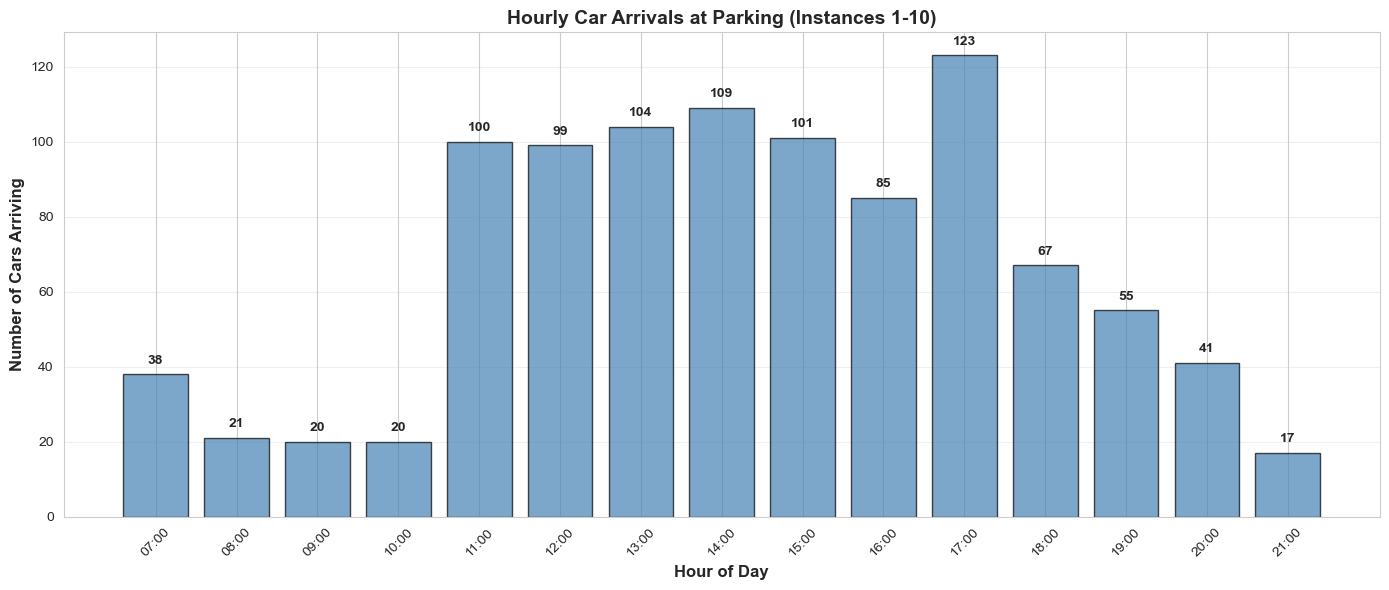


Peak hour: 17:00 with 123 arrivals


In [25]:
# Bar chart of hourly arrivals
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(hourly_summary['Hour_Formatted'], hourly_summary['Cars_Arriving'], 
       color='steelblue', edgecolor='black', alpha=0.7)

ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Cars Arriving', fontsize=12, fontweight='bold')
ax.set_title('Hourly Car Arrivals at Parking (Instances 1-10)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(hourly_summary['Cars_Arriving']):
    ax.text(i, v + 2, str(int(v)), ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nPeak hour: {hourly_summary.loc[hourly_summary['Cars_Arriving'].idxmax(), 'Hour_Formatted']} "
      f"with {int(hourly_summary['Cars_Arriving'].max())} arrivals")

## 9. Visualize Parking Duration by Arrival Hour

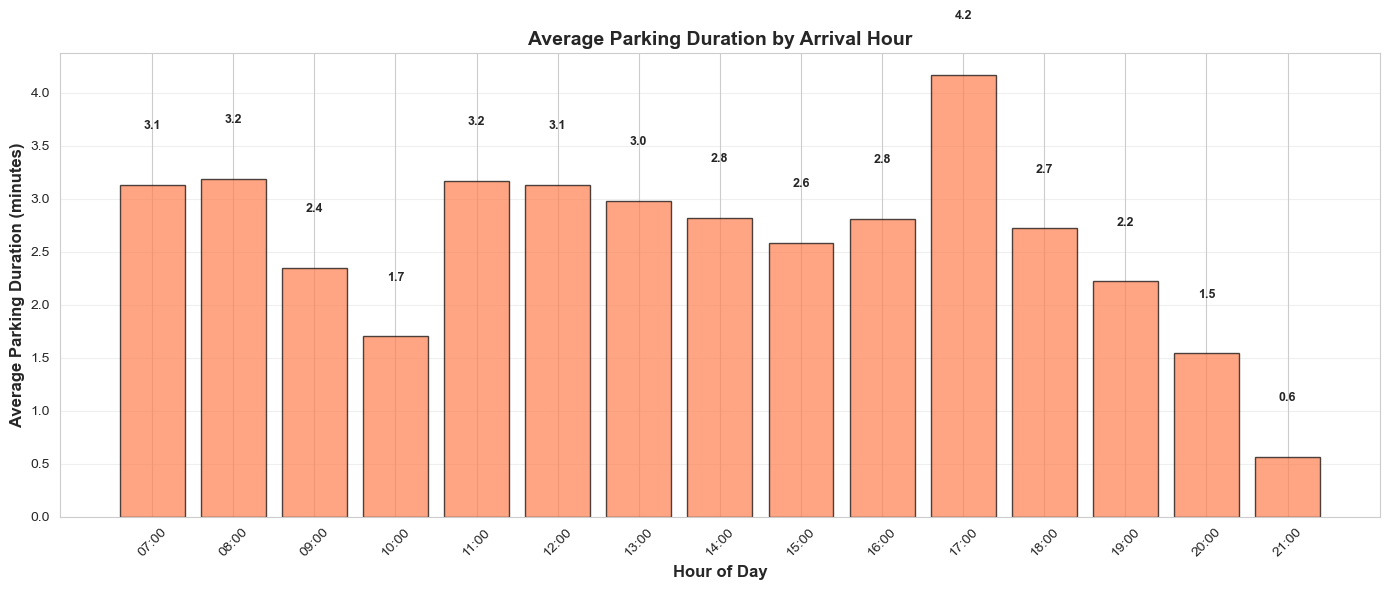

In [26]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(duration_by_hour['Hour_Formatted'], duration_by_hour['Avg_Duration_min'], 
       color='coral', edgecolor='black', alpha=0.7, label='Average Duration')

ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Parking Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Average Parking Duration by Arrival Hour', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(duration_by_hour['Avg_Duration_min']):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Box Plot: Duration Distribution by Hour

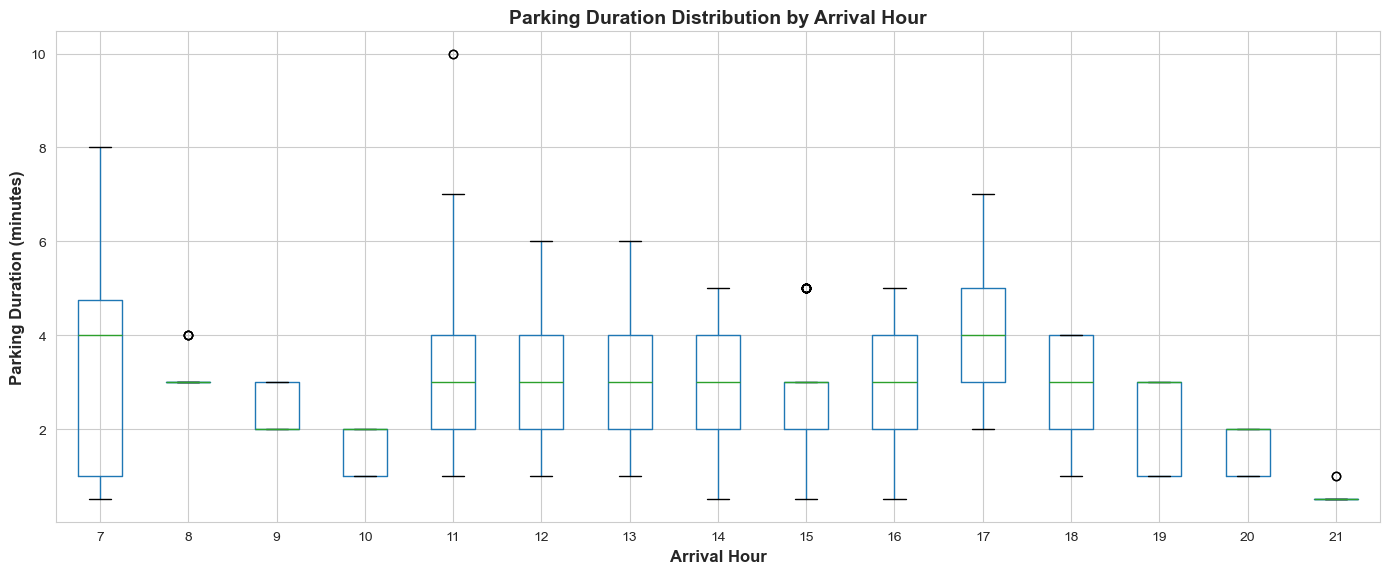

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

df_vehicles.boxplot(column='Parking_Duration', by='arrival_hour', ax=ax)

ax.set_xlabel('Arrival Hour', fontsize=12, fontweight='bold')
ax.set_ylabel('Parking Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_title('Parking Duration Distribution by Arrival Hour', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove the default title
plt.tight_layout()
plt.show()

## 11. Key Statistics Summary

In [28]:
print("\n" + "="*80)
print("OVERALL STATISTICS (All 10 Instances)")
print("="*80)

stats = {
    'Total Vehicles': len(df_vehicles),
    'Peak Hour': hourly_summary.loc[hourly_summary['Cars_Arriving'].idxmax(), 'Hour_Formatted'],
    'Max Arrivals in One Hour': int(hourly_summary['Cars_Arriving'].max()),
    'Average Duration (min)': f"{df_vehicles['Parking_Duration'].mean():.2f}",
    'Median Duration (min)': f"{df_vehicles['Parking_Duration'].median():.2f}",
    'Min Duration (min)': int(df_vehicles['Parking_Duration'].min()),
    'Max Duration (min)': int(df_vehicles['Parking_Duration'].max()),
    'Total Parking Hours': f"{(df_vehicles['Parking_Duration'].sum() / 60):.1f}"
}

for key, value in stats.items():
    print(f"{key:<40}: {value}")

print("\n" + "="*80)
print("USER TYPE BREAKDOWN")
print("="*80)
user_breakdown = df_vehicles['User_Type'].value_counts()
for user_type, count in user_breakdown.items():
    percentage = (count / len(df_vehicles)) * 100
    print(f"{user_type:<20}: {count:<10} ({percentage:.1f}%)")


OVERALL STATISTICS (All 10 Instances)
Total Vehicles                          : 1000
Peak Hour                               : 17:00
Max Arrivals in One Hour                : 123
Average Duration (min)                  : 2.90
Median Duration (min)                   : 3.00
Min Duration (min)                      : 0
Max Duration (min)                      : 10
Total Parking Hours                     : 48.3

USER TYPE BREAKDOWN
Visitor             : 949        (94.9%)
Staff               : 51         (5.1%)


## 12. Total Cars Present at Each Hour (Occupancy Analysis)

In [29]:
# Calculate total cars present at each hour
# A car is present at hour H if: Arrival_Time <= H*60 AND Departure_Time > H*60

def get_cars_at_hour(df, hour):
    """Count total cars parked at a given hour (including arrived and still parked)"""
    hour_minutes = hour * 60
    # Cars that have arrived by this hour AND haven't left yet
    cars_present = df[(df['Arrival_Time'] <= hour_minutes) & (df['Departure_Time'] > hour_minutes)]
    return len(cars_present)

# Calculate for all hours (0-23)
hours_range = range(0, 24)
occupancy_data = []

for hour in hours_range:
    cars_present = get_cars_at_hour(df_vehicles, hour)
    hour_formatted = f"{hour:02d}:00"
    
    # Also get arrivals and departures at this hour
    arrivals = len(df_vehicles[df_vehicles['arrival_hour'] == hour])
    departures = len(df_vehicles[(df_vehicles['Departure_Time'] // 60).astype(int) == hour])
    
    occupancy_data.append({
        'Hour': hour,
        'Hour_Formatted': hour_formatted,
        'Total_Cars_Present': cars_present,
        'New_Arrivals': arrivals,
        'Departures': departures
    })

df_occupancy = pd.DataFrame(occupancy_data)

print("\n" + "="*100)
print("PARKING OCCUPANCY: TOTAL CARS PRESENT AT EACH HOUR")
print("="*100)
print("\nIncludes all cars that have arrived AND haven't departed yet\n")
print(df_occupancy[['Hour', 'Hour_Formatted', 'Total_Cars_Present', 'New_Arrivals', 'Departures']].to_string(index=False))

print("\n" + "="*100)
print("OCCUPANCY STATISTICS")
print("="*100)
print(f"Peak Occupancy Hour    : {df_occupancy.loc[df_occupancy['Total_Cars_Present'].idxmax(), 'Hour_Formatted']}")
print(f"Max Cars Parked at Once: {df_occupancy['Total_Cars_Present'].max()}")
print(f"Min Cars Parked        : {df_occupancy['Total_Cars_Present'].min()}")
print(f"Average Occupancy      : {df_occupancy['Total_Cars_Present'].mean():.1f} cars")


PARKING OCCUPANCY: TOTAL CARS PRESENT AT EACH HOUR

Includes all cars that have arrived AND haven't departed yet

 Hour Hour_Formatted  Total_Cars_Present  New_Arrivals  Departures
    0          00:00                   0             0           0
    1          01:00                   0             0           0
    2          02:00                   0             0           0
    3          03:00                   0             0           0
    4          04:00                   0             0           0
    5          05:00                   0             0           0
    6          06:00                   0             0           0
    7          07:00                   2            38           0
    8          08:00                  37            21          15
    9          09:00                  44            20           0
   10          10:00                  64            20           0
   11          11:00                  90           100          49
   12         

## 13. Visualize Parking Occupancy Over Time

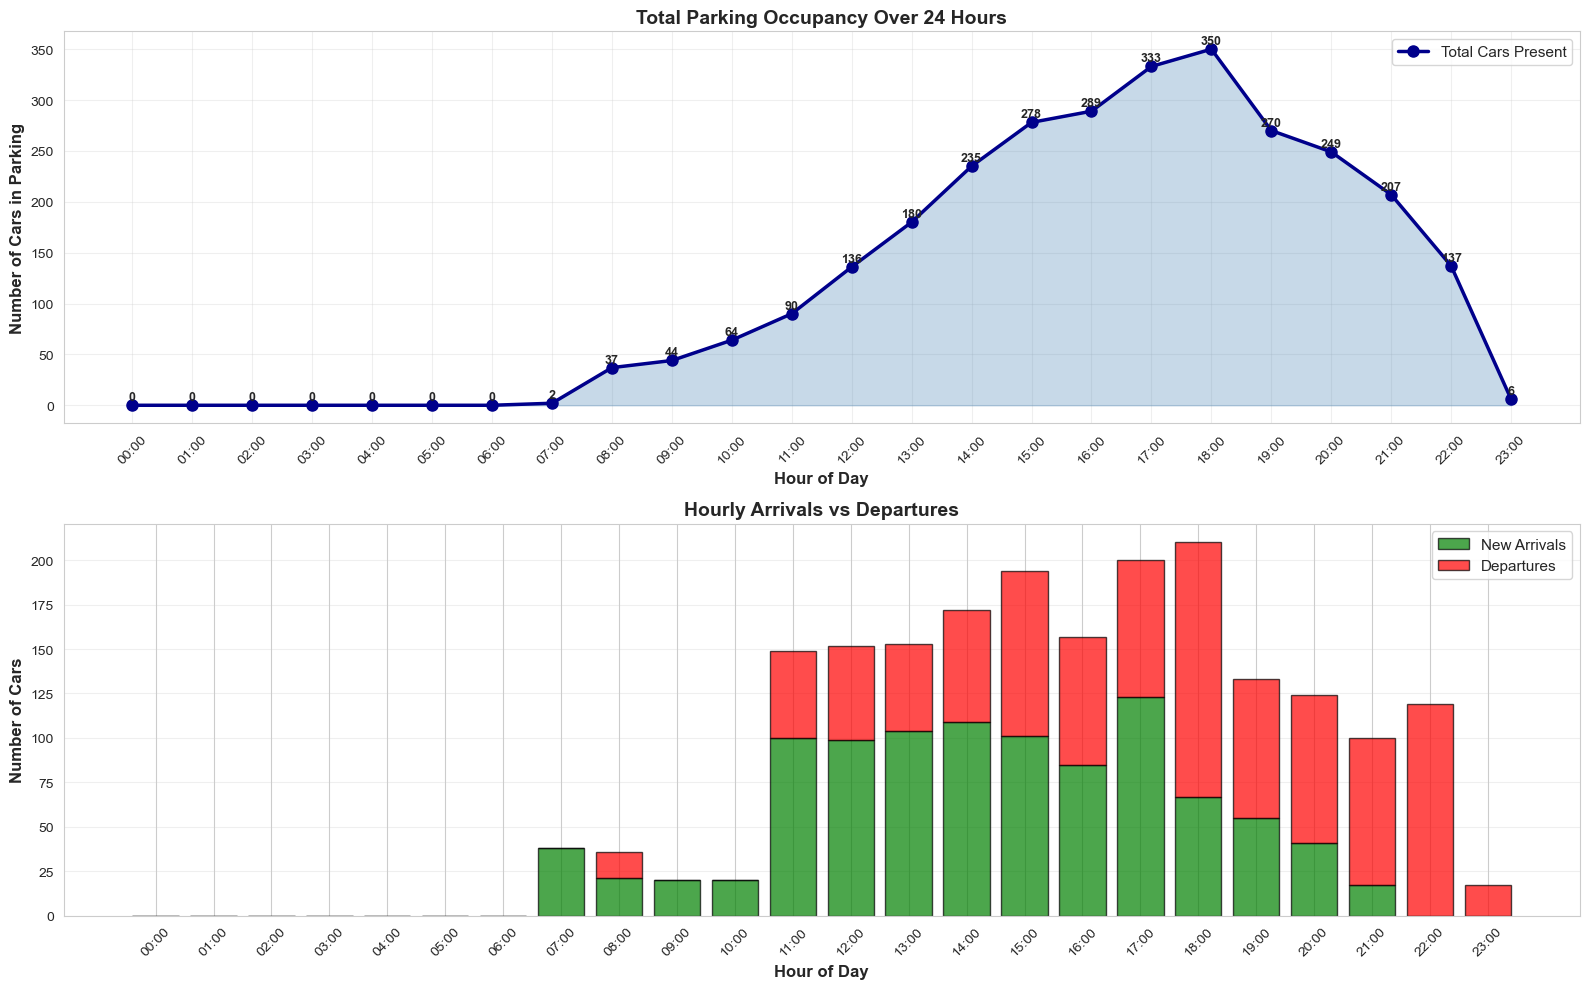


Visualization complete!


In [30]:
# Visualize occupancy over 24 hours
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Total cars present per hour (line chart)
axes[0].plot(df_occupancy['Hour_Formatted'], df_occupancy['Total_Cars_Present'], 
             marker='o', linewidth=2.5, markersize=8, color='darkblue', label='Total Cars Present')
axes[0].fill_between(range(len(df_occupancy)), df_occupancy['Total_Cars_Present'], 
                      alpha=0.3, color='steelblue')
axes[0].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Cars in Parking', fontsize=12, fontweight='bold')
axes[0].set_title('Total Parking Occupancy Over 24 Hours', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Add value labels
for i, v in enumerate(df_occupancy['Total_Cars_Present']):
    axes[0].text(i, v + 2, str(int(v)), ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_xticks(range(0, 24))
axes[0].set_xticklabels(df_occupancy['Hour_Formatted'], rotation=45)

# Plot 2: Stacked view of arrivals and departures
x = range(len(df_occupancy))
axes[1].bar(x, df_occupancy['New_Arrivals'], label='New Arrivals', color='green', alpha=0.7, edgecolor='black')
axes[1].bar(x, df_occupancy['Departures'], bottom=df_occupancy['New_Arrivals'], 
            label='Departures', color='red', alpha=0.7, edgecolor='black')

axes[1].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Cars', fontsize=12, fontweight='bold')
axes[1].set_title('Hourly Arrivals vs Departures', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticks(range(0, 24))
axes[1].set_xticklabels(df_occupancy['Hour_Formatted'], rotation=45)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

## 13. Visualize Parking Occupancy Over Time

## 12. Total Cars Present at Each Hour (Occupancy Analysis)